In [22]:
from PyHessian.pyhessian.hessian import hessian
from PyHessian.density_plot import get_esd_plot
from hessian_utils import *
from PyHessian.pyhessian.utils import *
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
# from keras.datasets import mnist
import matplotlib.pyplot as plt 
import time
import copy


# PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
%matplotlib inline

In [23]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)
cuda = torch.cuda.is_available()
torch.autograd.set_detect_anomaly(True)

cuda


In [24]:
mnist_trainset = datasets.MNIST(root='../data/mnist', train=True, download=True, transform=transforms.ToTensor())
mnist_fashion_trainset = datasets.FashionMNIST(root='../data/fashion_mnist', train=True, download=True, transform=transforms.ToTensor())
cifar_trainset = datasets.CIFAR10(root='../data/cifar10', train=True, download=True, transform=transforms.ToTensor())
# Getting mnist test data
mnist_testset = datasets.MNIST(root='../data/mnist', train=False, download=True, transform=transforms.ToTensor())
mnist_fashion_testset = datasets.FashionMNIST(root='../data/fashion_mnist', train=False, download=True, transform=transforms.ToTensor())
cifar_testset = datasets.CIFAR10(root='../data/cifar10', train=False, download=True, transform=transforms.ToTensor())

torch.manual_seed(42)

In [25]:
train_X = cifar_trainset.data
train_y = cifar_trainset.targets
test_X = cifar_testset.data
test_y = cifar_testset.targets

In [26]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)
        self.fc2 = nn.Linear(100, 30)
        self.fc3 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(16*7*7, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 16*7*7)
        x = self.linear(x)
        return x

class ConvNet3D(nn.Module):
    def __init__(self):
        super(ConvNet3D, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(40*8*8, 30),
            nn.ReLU(),
            nn.Linear(30, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 40*8*8)
        x = self.linear(x)
        return x

In [27]:
# train_X = (train_X / 255.0).to(device)
# test_X = (test_X / 255.0).to(device)
# train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
# test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

train_X = torch.tensor(train_X).permute(0, 3, 1, 2).float()
test_X = torch.tensor(test_X).permute(0, 3, 1, 2).float()
train_X = (train_X / 255.0).to(device)
test_X = (test_X / 255.0).to(device)
train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

In [28]:
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X[:1000], train_y[:1000]),
    batch_size=32, shuffle=True)

# train_loader = torch.utils.data.DataLoader(
#     torch.utils.data.TensorDataset(train_X, train_y),
#     batch_size=32, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(test_X, test_y),
    batch_size=32, shuffle=False)


hessian_loader = (train_X[:50], train_y[:50])

In [29]:
model_base = ConvNet3D().to(device)
model_SGD = copy.deepcopy(model_base)
model_Adam = copy.deepcopy(model_base)
model_curvy = copy.deepcopy(model_base)

criterion = nn.CrossEntropyLoss()
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=1e-1, momentum=0.9)
optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr=5e-3)
optimizer_curvy = torch.optim.SGD(model_curvy.parameters(), lr=1e-3, momentum=0.9)

In [30]:
train_losses_SGD = []
train_losses_Adam = []
train_losses_curvy = []

adam_traces = []
sgd_traces = []
curvy_traces = []

test_loss_SGD = []
test_loss_Adam = []
test_loss_curvy = []

test_accuracy_SGD = []
test_accuracy_Adam = []
test_accuracy_curvy = []

model_distance_SGD = []
model_distance_Adam = []
model_distance_curvy = []

epochs = 100
n_iter = 100

In [31]:
def plot_curvature(curvature, blocks = None, nodesin = None, title = 'Curvature'):
    # Add incides of parameter blocks to the plot
    

    if blocks is not None:
        flattened_curvature = np.concatenate([np.array(c.cpu()).flatten() for c in [curvature[block] for block in blocks]])
        numels = [curvature[block].numel() for block in blocks]
        indices = [0] + list(np.cumsum(numels))

    else:
        flattened_curvature = np.concatenate([np.array(c.cpu()).flatten() for c in curvature])
        numels = [curvature[i].numel() for i in range(len(curvature))]
        indices = [0] + list(np.cumsum(numels))
        
    

    for i in range(len(indices)):
        plt.axvline(x=indices[i], color='r', linestyle='--', label=f'Block {i+1}')
    
    plt.plot(flattened_curvature, label="Curvature")
    plt.xlabel('Index')
    plt.ylabel('Curvature Value')
    plt.title(title)
    # plt.legend()
    plt.show()

def mean_curvature(curvature):
    import numpy as np
    return [torch.tensor(np.mean([curvature[i][j] for i in range(len(curvature))], axis=0)).to(device) for j in range(len(curvature[0]))]

def distance(model1, model2):
    return sum([torch.norm(p1 - p2) for p1, p2 in zip(model1.parameters(), model2.parameters())])

def accuracy(model, test_loader):
    accuracy = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            accuracy += (predicted == labels).sum().item()
    return accuracy / total

def get_loss(model, loader):
    total_loss = 0
    total_items = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss_value = criterion(outputs, labels)
            total_loss += loss_value.item() * inputs.size(0)
            total_items += inputs.size(0)
    return total_loss / total_items

In [32]:
hessian_SGD = hessian(model_SGD, criterion, data = hessian_loader, cuda=cuda)
hessian_Adam = hessian(model_Adam, criterion, data = hessian_loader, cuda=cuda)
hessian_curvy = hessian(model_curvy, criterion, data = hessian_loader, cuda=cuda)

curvature_SGD = (hessian_SGD.curvature_array(n_iter, 1e-3))
curvature_Adam = (hessian_Adam.curvature_array(n_iter, 1e-3))
curvature_curvy = (hessian_curvy.curvature_array(n_iter, 1e-3))

mean_curvature_SGD = mean_curvature(curvature_SGD)
mean_curvature_Adam = mean_curvature(curvature_Adam)
mean_curvature_curvy = mean_curvature(curvature_curvy)

model_distance_SGD.append(distance(model_SGD, model_base))
model_distance_Adam.append(distance(model_Adam, model_base))
model_distance_curvy.append(distance(model_curvy, model_base))


/tmp/ipykernel_3678826/2470632129.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  flattened_curvature = np.concatenate([np.array(c.cpu()).flatten() for c in curvature])


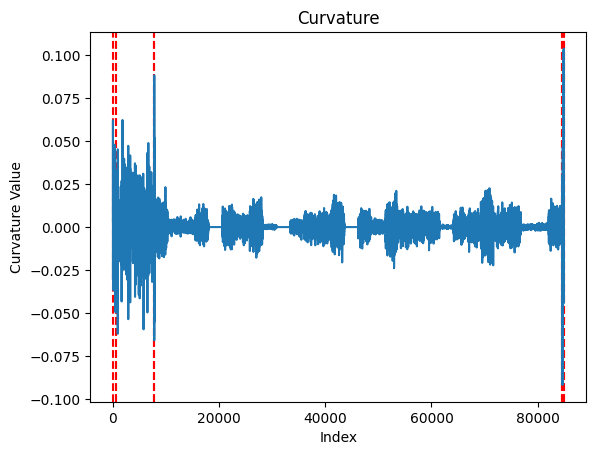

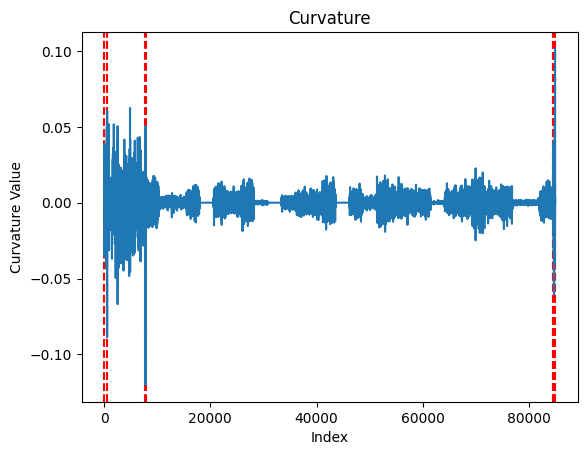

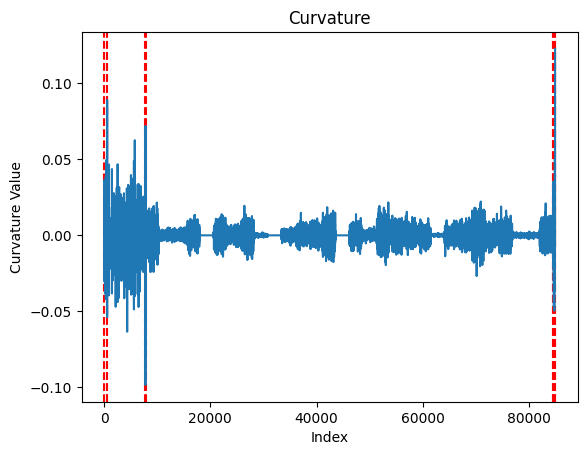

In [33]:
plot_curvature(mean_curvature_SGD)
plot_curvature(mean_curvature_Adam)
plot_curvature(mean_curvature_curvy)

In [ ]:
for epoch in range(epochs):
    model_SGD.train()
    model_Adam.train()
    model_curvy.train()

    running_loss_SGD = 0.0
    running_loss_Adam = 0.0
    running_loss_curvy = 0.0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # curvy_hessian_loader = (inputs, labels)
        # hessian_curvy = hessian(model_curvy, criterion, data = curvy_hessian_loader, cuda=cuda)
        # curvature_curvy = hessian_curvy.curvature_array(n_iter, 1e-3)
        # mean_curvature_curvy = mean_curvature(curvature_curvy)



        # Zero the parameter gradients
        optimizer_SGD.zero_grad()
        optimizer_Adam.zero_grad()
        optimizer_curvy.zero_grad()

        # Forward pass
        outputs_SGD = model_SGD(inputs)
        outputs_Adam = model_Adam(inputs)
        outputs_curvy = model_curvy(inputs)

        # Compute loss
        loss_SGD = criterion(outputs_SGD, labels)
        loss_Adam = criterion(outputs_Adam, labels)
        loss_curvy = criterion(outputs_curvy, labels)

        # Backward pass and optimize
        loss_SGD.backward()
        loss_Adam.backward()
        loss_curvy.backward()

        # parami = 0
        for param, cur in zip(model_curvy.parameters(), mean_curvature_curvy):
            # if parami == 4:
            #     break
            if param.grad is None:
                continue
            # h_tensor = torch.from_numpy(cur).to(param.device).to(param.dtype)
            param.grad = param.grad/torch.max(torch.abs(cur), torch.ones_like(cur) * 1e-2)
            # parami += 1

                

        optimizer_SGD.step()
        optimizer_Adam.step()
        optimizer_curvy.step()


        running_loss_SGD += loss_SGD.item()
        running_loss_Adam += loss_Adam.item()
        running_loss_curvy += loss_curvy.item()
        # print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(dataloader)}], Loss SGD: {loss_SGD.item():.4f}, Loss Adam: {loss_Adam.item():.4f}, loss Curvy: {loss_curvy.item():.4f}")

    train_losses_SGD.append(running_loss_SGD / len(dataloader))
    train_losses_Adam.append(running_loss_Adam / len(dataloader))
    train_losses_curvy.append(running_loss_curvy / len(dataloader))

    model_distance_SGD.append(distance(model_SGD, model_base))
    model_distance_Adam.append(distance(model_Adam, model_base))
    model_distance_curvy.append(distance(model_curvy, model_base))

    print(f"Epoch [{epoch+1}/{epochs}], Loss SGD: {train_losses_SGD[-1]:.4f}, Loss Adam: {train_losses_Adam[-1]:.4f}, loss Curvy: {train_losses_curvy[-1]:.4f}")
    # Plot curvature array
    # print(f"Epoch [{epoch+1}/{epochs}], Loss Adam: {train_losses_Adam[-1]:.4f}")
    indices = torch.randperm(train_X.size(0))[:50]
    random_hessian_loader = (train_X[indices], train_y[indices])

    # hessian_SGD = hessian(model_SGD, criterion, data = random_hessian_loader, cuda=cuda)
    # hessian_Adam = hessian(model_Adam, criterion, data = random_hessian_loader, cuda=cuda)
    hessian_curvy = hessian(model_curvy, criterion, data = random_hessian_loader, cuda=cuda)

    # curvature_SGD = hessian_SGD.curvature_array(n_iter, 1e-3)
    # curvature_Adam = hessian_Adam.curvature_array(n_iter, 1e-3)
    curvature_curvy = hessian_curvy.curvature_array(n_iter, 1e-3)

    # mean_curvature_SGD = mean_curvature(curvature_SGD)
    # mean_curvature_Adam = mean_curvature(curvature_Adam)
    mean_curvature_curvy = mean_curvature(curvature_curvy)
    
    # adam_traces.append(np.mean(hessian_Adam.trace(maxIter= 10)))
    # sgd_traces.append(np.mean(hessian_SGD.trace(maxIter= 10)))
    # curvy_traces.append(np.mean(hessian_curvy.trace(maxIter= 10)))

    # test_loss_Adam.append(loss(model_Adam, test_loader))
    # test_loss_SGD.append(loss(model_SGD, test_loader))
    # test_loss_curvy.append(loss(model_curvy, test_loader))

    # test_accuracy_SGD.append(accuracy(model_SGD, test_loader))
    # test_accuracy_Adam.append(accuracy(model_Adam, test_loader))
    # test_accuracy_curvy.append(accuracy(model_curvy, test_loader))

    
    # print(f"Epoch [{epoch+1}/{epochs}], Test Loss SGD: {test_loss_SGD[-1]:.4f}, Test Loss Adam: {test_loss_Adam[-1]:.4f}, Test Loss Curvy: {test_loss_curvy[-1]:.4f}")
    # print(f"Epoch [{epoch+1}/{epochs}], Test Accuracy SGD: {accuracy(model_SGD, test_loader):.4f}, Accuracy Adam: {accuracy(model_Adam, test_loader):.4f}, Accuracy Curvy: {accuracy(model_curvy, test_loader):.4f}")
    # print(f"Epoch [{epoch+1}/{epochs}], Distance SGD: {model_distance_SGD[-1]:.4f}, Distance Adam: {model_distance_Adam[-1]:.4f}, Distance Curvy: {model_distance_curvy[-1]:.4f}")
    # print(f"Epoch [{epoch+1}/{epochs}], Trace SGD: {sgd_traces[-1]:.4f}, Trace Adam: {adam_traces[-1]:.4f}, Trace Curvy: {curvy_traces[-1]:.4f}")
    
    # plot_curvature(mean_curvature_SGD, title = f'Curvature SGD epoch {epoch+1}')
    # plot_curvature(mean_curvature_Adam, title = f'Curvature Adam epoch {epoch+1}')
    # plot_curvature(mean_curvature_curvy, title = f'Curvature Curvy epoch {epoch+1}')

Epoch [1/100], Loss SGD: 2.3060, Loss Adam: 2.2544, loss Curvy: 2.3026


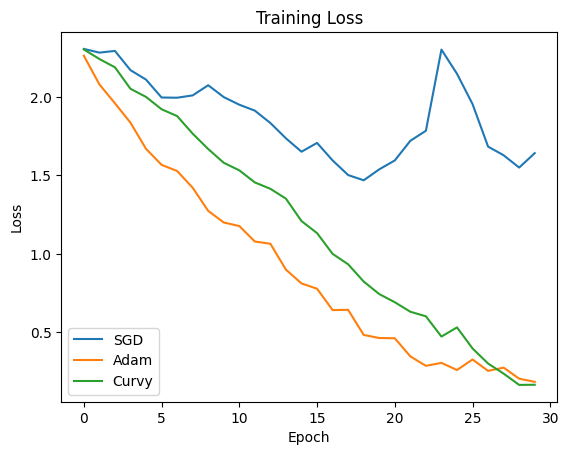

In [ ]:
plt.plot(train_losses_SGD, label='SGD')
plt.plot(train_losses_Adam, label='Adam')
plt.plot(train_losses_curvy, label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

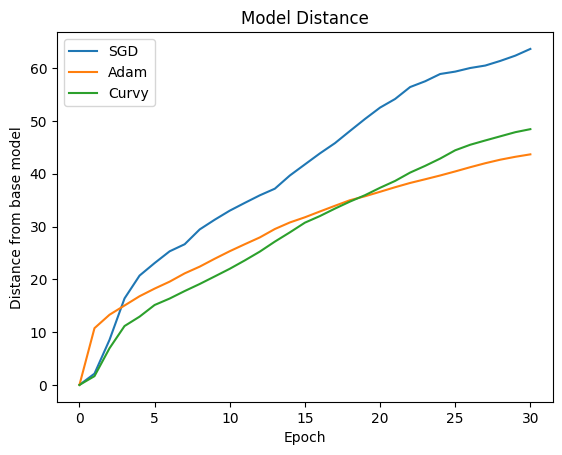

In [ ]:
plt.plot([model_distance_SGD[i].detach().item() for i in range(len(model_distance_SGD))], label='SGD')
plt.plot([model_distance_Adam[i].detach().item() for i in range(len(model_distance_Adam))], label='Adam')
plt.plot([model_distance_curvy[i].detach().item() for i in range(len(model_distance_curvy))], label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Distance from base model')
plt.title('Model Distance')
plt.legend()
plt.show()

In [ ]:
distance(model_curvy, model_Adam), distance(model_curvy, model_SGD), distance(model_Adam, model_SGD)

(tensor(63.3148, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(76.5936, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(77.8262, device='cuda:0', grad_fn=<AddBackward0>))

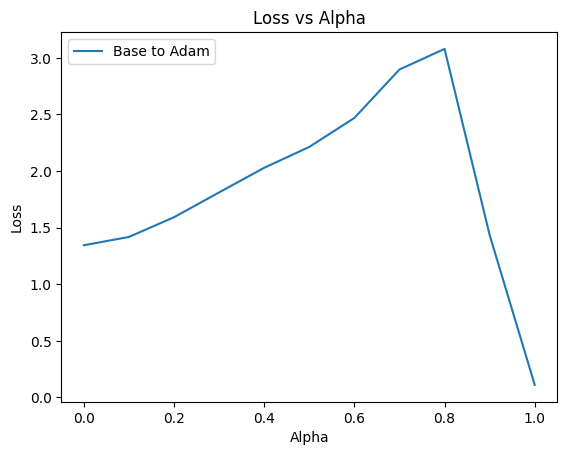

In [ ]:
def get_intermediate_model(model1, model2, alpha):
    """
    Get a model that is a linear combination of model1 and model2.
    """
    model = copy.deepcopy(model1)
    for param1, param2 in zip(model.parameters(), model2.parameters()):
        param1.data = (1 - alpha) * param1.data + alpha * param2.data
    return model


losses = []
my_range = np.arange(0, 1.1, 0.1)
for i in my_range:
    model = get_intermediate_model(model_SGD, model_curvy, i)
    with torch.no_grad():
        
        losss = get_loss(model, dataloader)
        losses.append(losss)
plt.plot(my_range, losses, label='Base to Adam')
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.title('Loss vs Alpha')
plt.legend()
plt.show()



/home/aarsh.wankar/Hessian/DeepHessian/PyHessian/density_plot.py:72: ComplexWarning: Casting complex values to real discards the imaginary part
  density_output[i, j] = np.sum(tmp_result * weights[i, :])


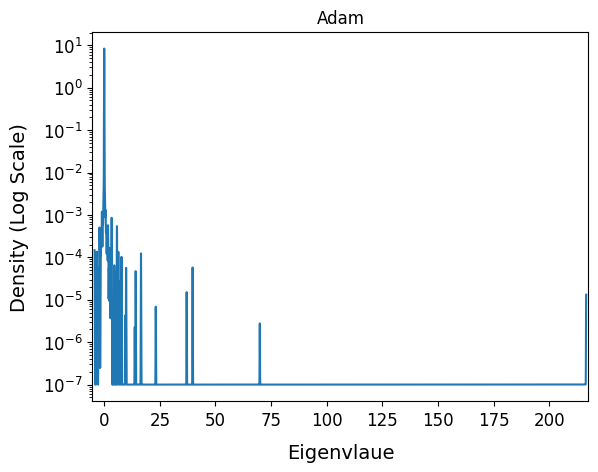

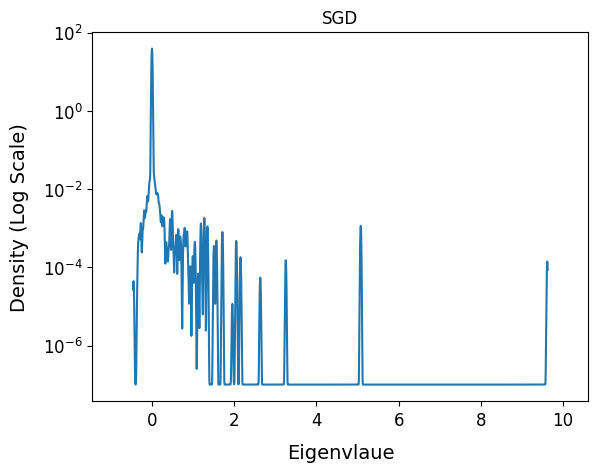

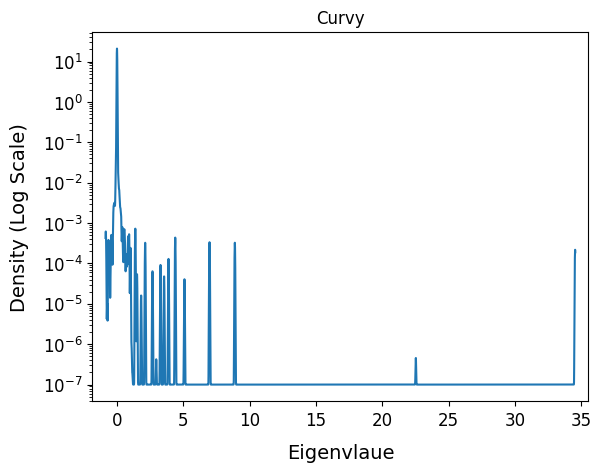

In [ ]:
hessian_SGD = hessian(model_SGD, criterion, data = hessian_loader, cuda=cuda)
hessian_Adam = hessian(model_Adam, criterion, data = hessian_loader, cuda=cuda)
hessian_curvy = hessian(model_curvy, criterion, data = hessian_loader, cuda=cuda)

get_esd_plot(*hessian_Adam.density(), title='Adam')
get_esd_plot(*hessian_SGD.density(), title='SGD')
get_esd_plot(*hessian_curvy.density(), title='Curvy')

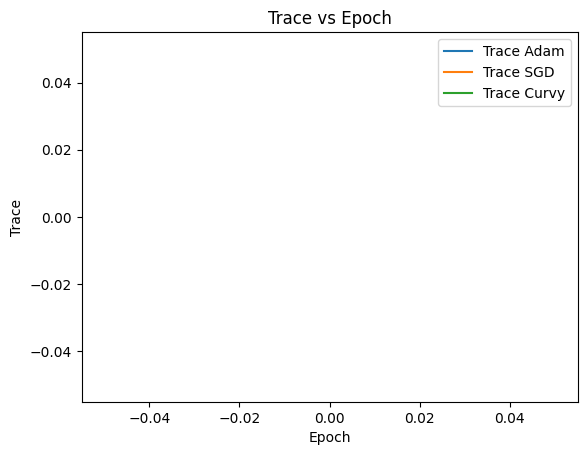

In [ ]:
plt.plot(adam_traces, label='Trace Adam')
plt.plot(sgd_traces, label='Trace SGD')
plt.plot(curvy_traces, label='Trace Curvy')
plt.xlabel('Epoch')
plt.ylabel('Trace')
plt.title('Trace vs Epoch')
plt.legend()
plt.show()

In [ ]:
# Finding accuracy on train and test data
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X, train_y),
    batch_size=32, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(test_X, test_y),
    batch_size=32, shuffle=False)

def test_model(model, test_loader):
    accuracy = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            accuracy += (predicted == labels).sum().item()
    return accuracy / total

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X, train_y),
    batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(test_X, test_y),
    batch_size=32, shuffle=False)


accuracy_SGD = get_loss(model_SGD, test_loader)
accuracy_Adam = get_loss(model_Adam, test_loader)
accuracy_curvy = get_loss(model_curvy, test_loader)

print(f"Accuracy SGD: {accuracy_SGD:.4f}")
print(f"Accuracy Adam: {accuracy_Adam:.4f}")
print(f"Accuracy Curvy: {accuracy_curvy:.4f}")


Accuracy SGD: 2.9871
Accuracy Adam: 4.2923
Accuracy Curvy: 3.8527


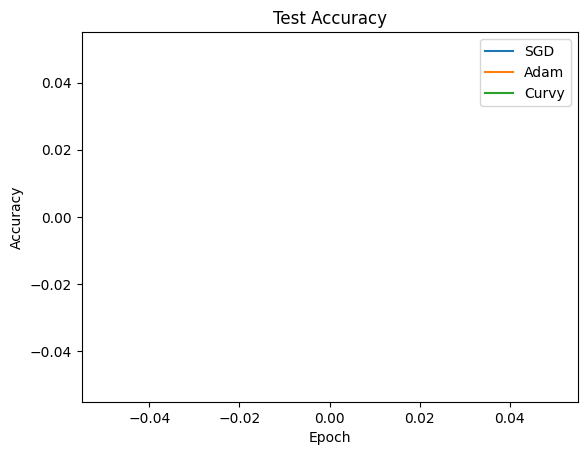

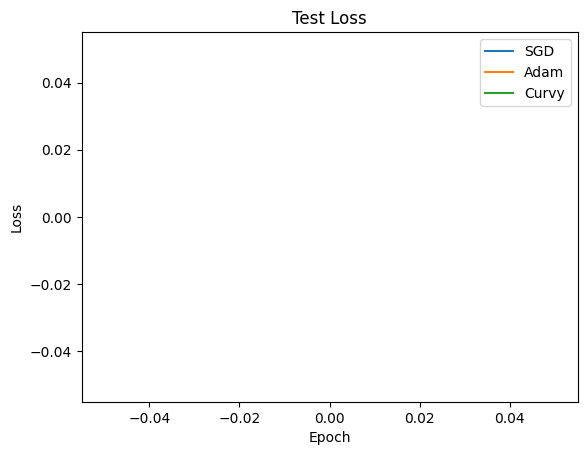

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [ ]:
plt.plot(test_accuracy_SGD, label='SGD')
plt.plot(test_accuracy_Adam, label='Adam')
plt.plot(test_accuracy_curvy, label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()
plt.show()

plt.plot(test_loss_SGD, label='SGD')
plt.plot(test_loss_Adam, label='Adam')
plt.plot(test_loss_curvy, label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Test Loss')
plt.legend()
plt.show()

plt.plot(model_distance_SGD, label='SGD')
plt.plot(model_distance_Adam, label='Adam')
plt.plot(model_distance_curvy, label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Distance from base model')
plt.title('Model Distance')
plt.legend()
plt.show()



/home/aarsh.wankar/Hessian/DeepHessian/PyHessian/density_plot.py:72: ComplexWarning: Casting complex values to real discards the imaginary part
  density_output[i, j] = np.sum(tmp_result * weights[i, :])


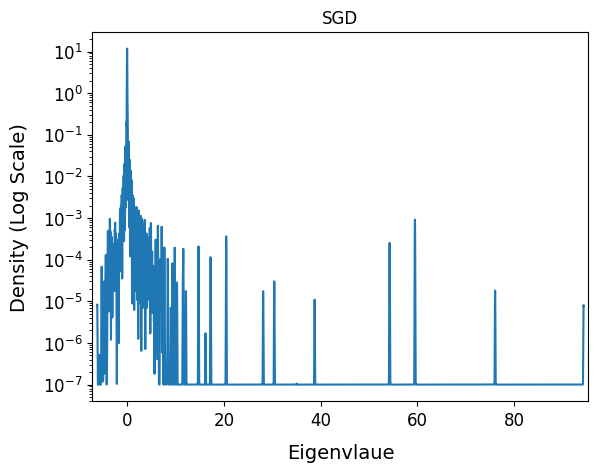

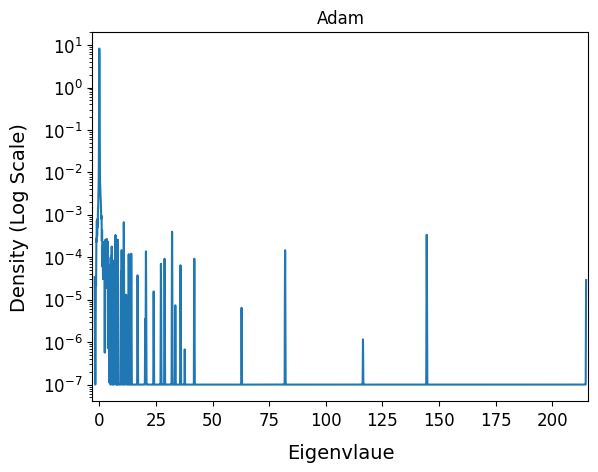

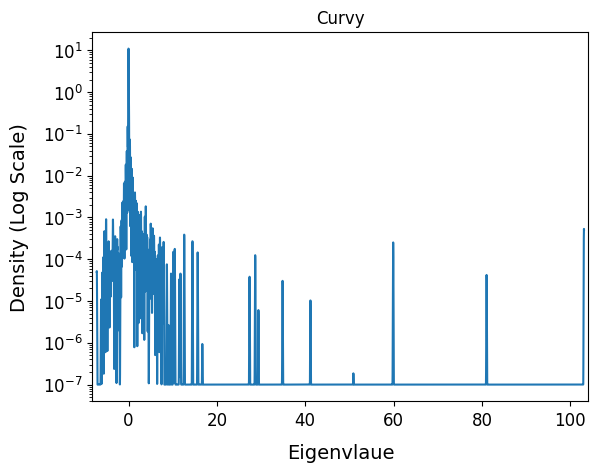

In [ ]:
hessian_SGD = hessian(model_SGD, criterion, data = hessian_loader, cuda=cuda)
hessian_Adam = hessian(model_Adam, criterion, data = hessian_loader, cuda=cuda)
hessian_curvy = hessian(model_curvy, criterion, data = hessian_loader, cuda=cuda)

get_esd_plot(*hessian_SGD.density(), title='SGD')
get_esd_plot(*hessian_Adam.density(), title='Adam')
get_esd_plot(*hessian_curvy.density(), title='Curvy')